# Sensorless Drive Diagnosis

Notebook base para cargar y analizar el dataset `Sensorless_drive_diagnosis.txt`, que viene sin encabezado y separado por espacios.

## 1. Carga del dataset

El archivo no trae encabezados, así que se leen 48 variables y una etiqueta final. En el notebook se asignan nombres genéricos `feature_01` a `feature_48` y `target`.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path(r"C:\Users\elmer\Documents\SIS420\EXAMEN\datasets\dataset+for+sensorless+drive+diagnosis\Sensorless_drive_diagnosis.txt")
COLUMN_NAMES = [f"caracteristica_{i:02d}" for i in range(1, 49)] + ["objetivo"]

df = pd.read_csv(DATA_PATH, sep=r"\s+", header=None, names=COLUMN_NAMES)
print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (58509, 49)


,caracteristica_01,caracteristica_02,caracteristica_03,caracteristica_04,caracteristica_05,caracteristica_06,caracteristica_07,caracteristica_08,caracteristica_09,caracteristica_10,...,caracteristica_40,caracteristica_41,caracteristica_42,caracteristica_43,caracteristica_44,caracteristica_45,caracteristica_46,caracteristica_47,caracteristica_48,objetivo
0,-3.014600e-07,8.260300e-06,-0.000012,-0.000002,-1.438600e-06,-0.000021,0.031718,0.031710,0.031721,-0.032963,...,-0.63308,2.9646,8.1198,-1.4961,-1.4961,-1.4961,-1.4996,-1.4996,-1.4996,1
1,2.913200e-06,-5.247700e-06,0.000003,-0.000006,2.778900e-06,-0.000004,0.030804,0.030810,0.030806,-0.033520,...,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
2,-2.951700e-06,-3.184000e-06,-0.000016,-0.000001,-1.575300e-06,0.000017,0.032877,0.032880,0.032896,-0.029834,...,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
3,-1.322600e-06,8.820100e-06,-0.000016,-0.000005,-7.282900e-07,0.000004,0.029410,0.029401,0.029417,-0.030156,...,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
4,-6.836600e-08,5.666300e-07,-0.000026,-0.000006,-7.940600e-07,0.000013,0.030119,0.030119,0.030145,-0.031393,...,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1


## 2. Revisión rápida

Separamos variables predictoras y etiqueta para confirmar que el conjunto está bien cargado.

In [12]:
X = df.drop(columns=["objetivo"])
y = df["objetivo"]

print("Cantidad de observaciones:", len(df))
print("Cantidad de variables:", X.shape[1])
print("Clases únicas:", sorted(y.unique()))
print("Valores faltantes por columna:")
print(df.isna().sum().head())
print("\nEstadísticas generales:")
print(df.describe().T.head())

Cantidad de observaciones: 58509
Cantidad de variables: 48
Clases únicas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Valores faltantes por columna:
caracteristica_01    0
caracteristica_02    0
caracteristica_03    0
caracteristica_04    0
caracteristica_05    0
dtype: int64

Estadísticas generales:
                     count      mean       std       min       25%  \
caracteristica_01  58509.0 -0.000003  0.000072 -0.013721 -0.000007   
caracteristica_02  58509.0  0.000001  0.000056 -0.005414 -0.000014   
caracteristica_03  58509.0  0.000001  0.000235 -0.013580 -0.000072   
caracteristica_04  58509.0 -0.000001  0.000063 -0.012787 -0.000005   
caracteristica_05  58509.0  0.000001  0.000057 -0.008356 -0.000015   

                            50%       75%       max  
caracteristica_01 -2.652600e-06  0.000002  0.005784  
caracteristica_02  8.804600e-07  0.000019  0.004525  
caracteristic

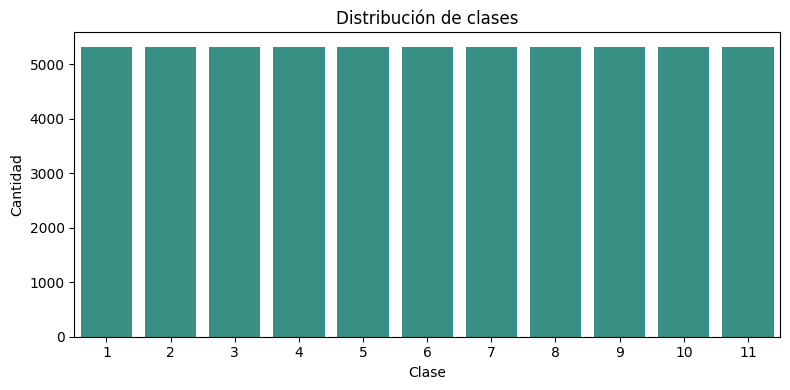

In [13]:
plt.figure(figsize=(8, 4))
sns.countplot(x=y, color="#2a9d8f")
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

## 3. Modelo base

Usamos una división estratificada y un clasificador lineal como referencia rápida. Si luego quieres más precisión, se puede probar RandomForest, SVM o redes neuronales.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

modelo = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000)),
    ]
)

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9193300290548624

Reporte de clasificación:

              precision    recall  f1-score   support

           1       0.96      0.96      0.96      1063
           2       0.90      0.88      0.89      1064
           3       0.96      0.96      0.96      1064
           4       0.96      0.96      0.96      1064
           5       0.86      0.82      0.84      1064
           6       0.85      0.85      0.85      1063
           7       1.00      1.00      1.00      1064
           8       0.87      0.91      0.89      1064
           9       0.87      0.87      0.87      1064
          10       0.89      0.91      0.90      1064
          11       1.00      1.00      1.00      1064

    accuracy                           0.92     11702
   macro avg       0.92      0.92      0.92     11702
weighted avg       0.92      0.92      0.92     11702



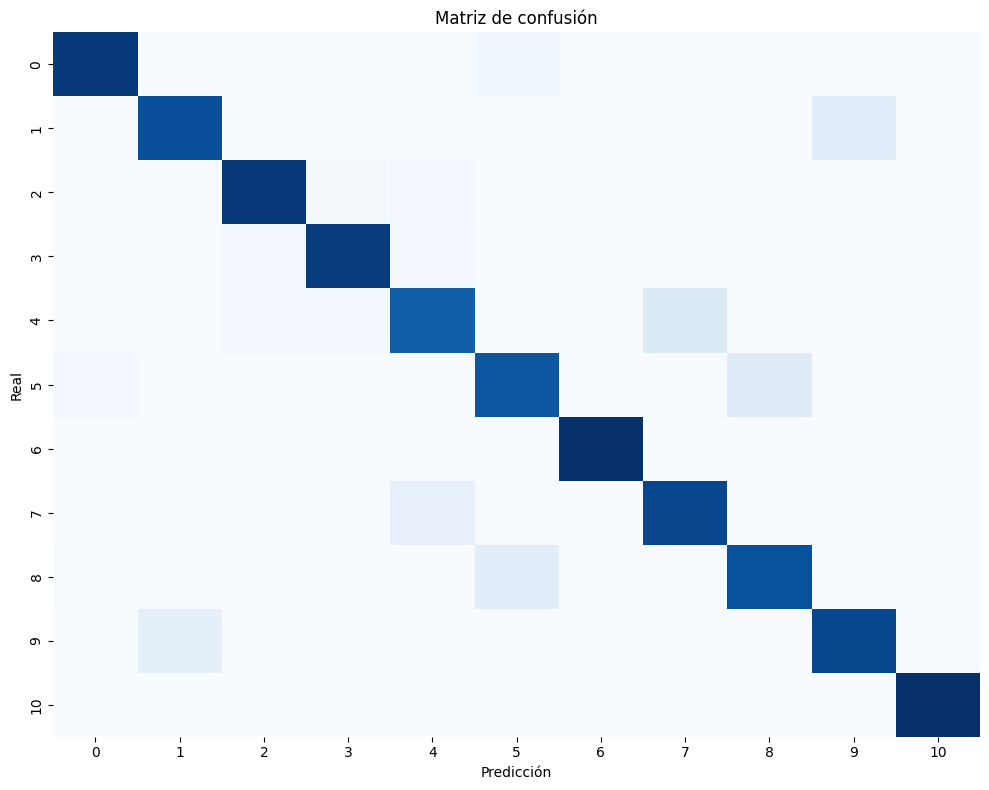

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 4. Siguiente paso sugerido

Si quieres mejorar el rendimiento, el siguiente paso es probar `RandomForestClassifier`, `SVC` o una red neuronal con PyTorch.

## 5. Clustering con KMeans

Como KMeans es un método no supervisado, primero escalamos los datos y luego usamos las tres variables con mayor variabilidad para visualizar la dispersión en 3D. Se evaluarán $k=3$, $5$, $7$ y $9$.

Variables elegidas para el 3D: ['caracteristica_40', 'caracteristica_37', 'caracteristica_41']
 k      inertia  silhouette
 3 2.257013e+06    0.174117
 5 1.935781e+06    0.141339
 7 1.709726e+06    0.147497
 9 1.556104e+06    0.162184


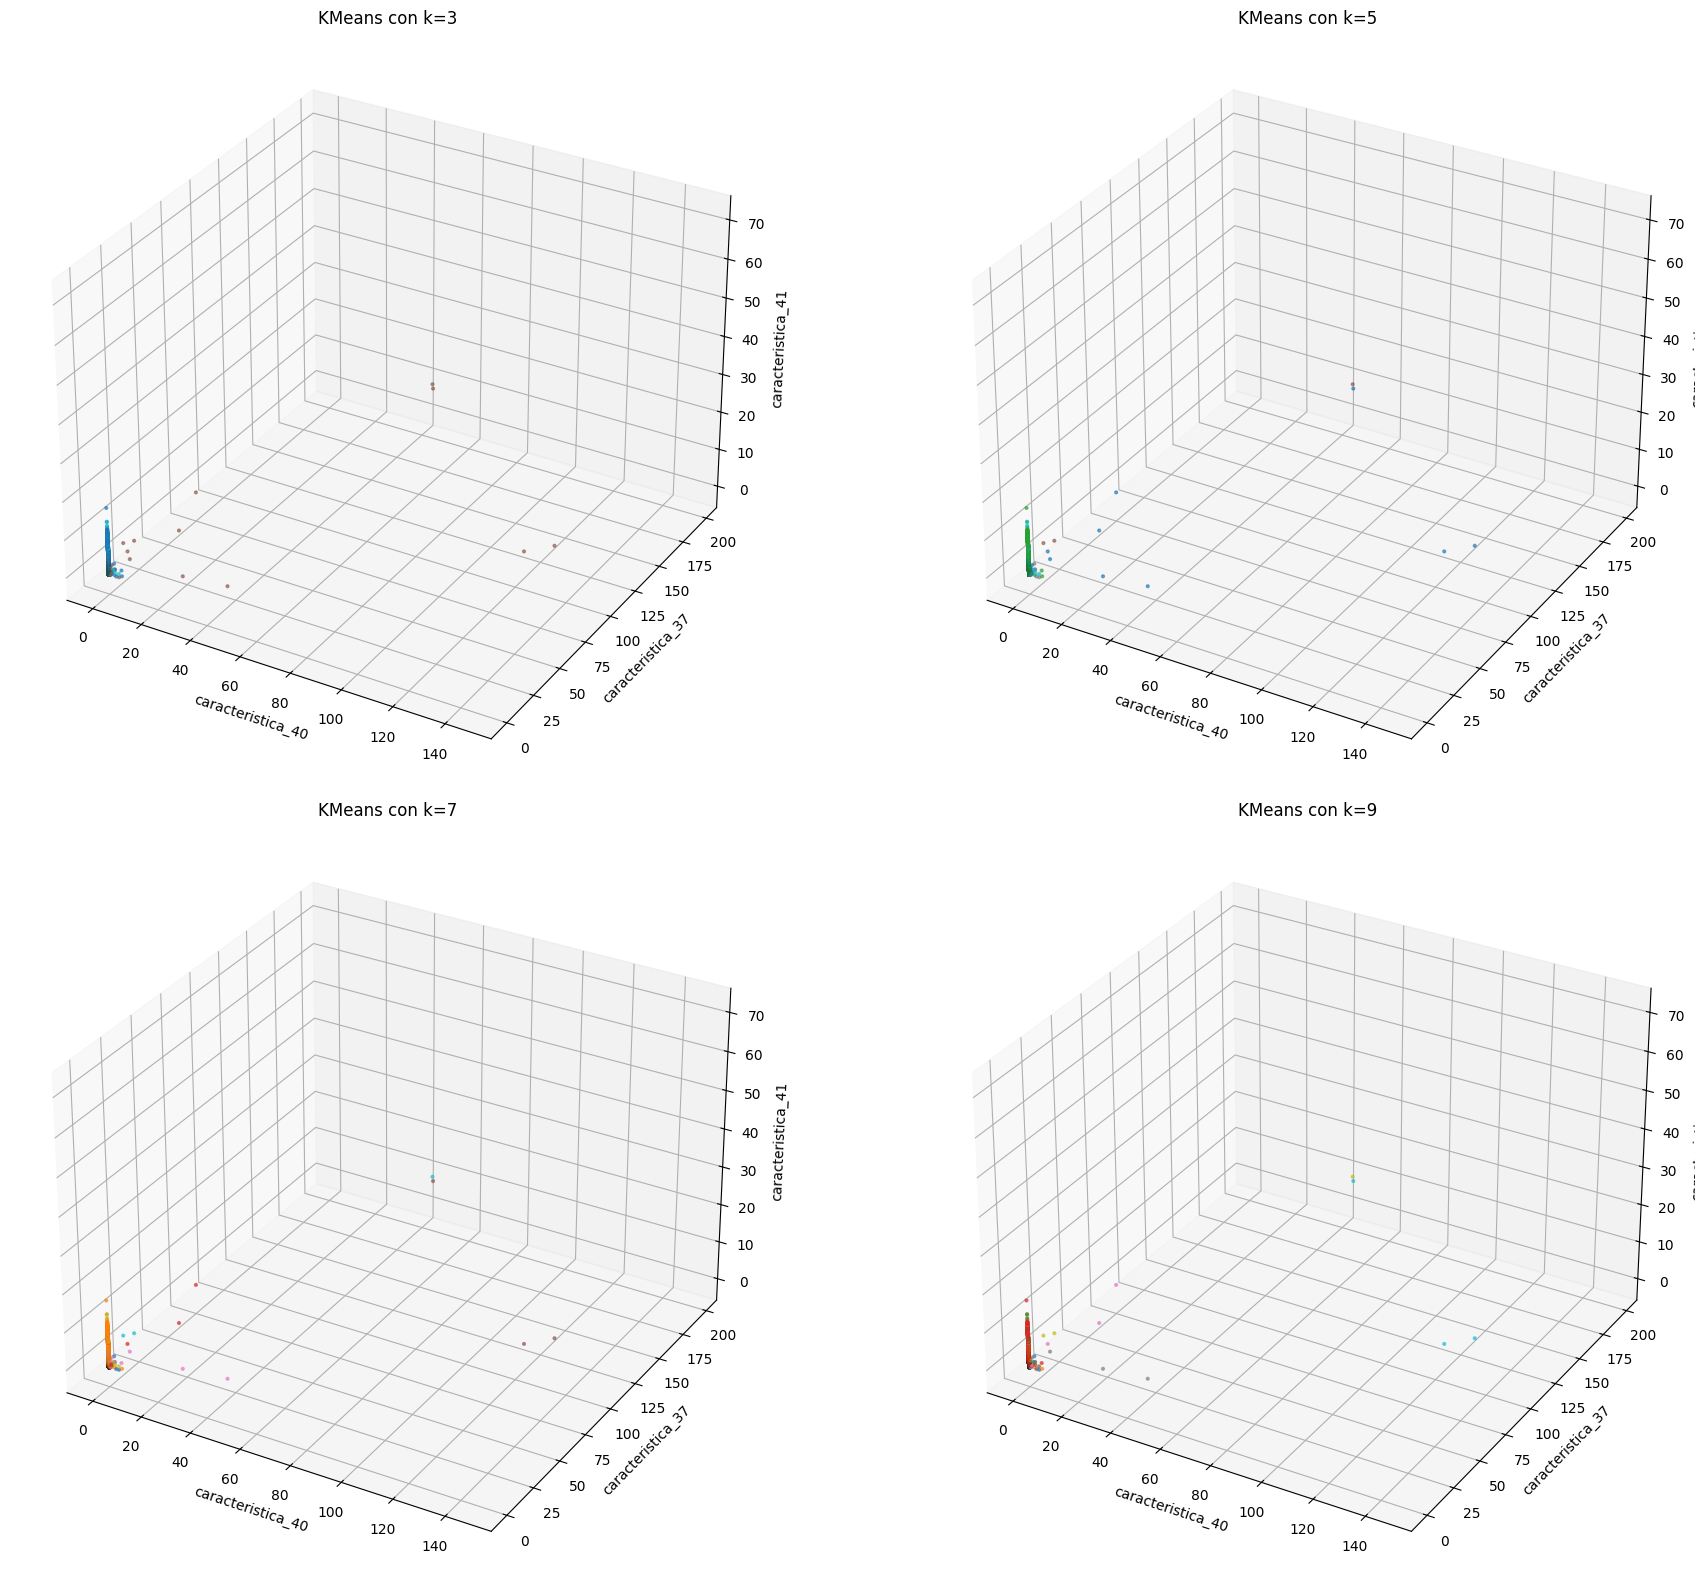

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Escalado previo para KMeans
X_scaled = StandardScaler().fit_transform(X)

# Tomamos las 3 variables con mayor variabilidad para la visualización 3D
top_features = X.var().sort_values(ascending=False).head(3).index.tolist()
print("Variables elegidas para el 3D:", top_features)

X_top3 = df[top_features]
X_top3_scaled = StandardScaler().fit_transform(X_top3)

ks = [3, 5, 7, 9]
resultados = []
fig = plt.figure(figsize=(20, 16))

for i, k in enumerate(ks, start=1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    sil = silhouette_score(X_scaled, labels)
    resultados.append({"k": k, "inertia": inertia, "silhouette": sil})

    ax = fig.add_subplot(2, 2, i, projection="3d")
    ax.scatter(
        X_top3_scaled[:, 0],
        X_top3_scaled[:, 1],
        X_top3_scaled[:, 2],
        c=labels,
        cmap="tab10",
        s=4,
        alpha=0.6,
    )
    ax.set_title(f"KMeans con k={k}")
    ax.set_xlabel(top_features[0])
    ax.set_ylabel(top_features[1])
    ax.set_zlabel(top_features[2])

resultados_df = pd.DataFrame(resultados)
print(resultados_df.to_string(index=False))
plt.tight_layout()
plt.show()

### Interpretación de los resultados

- Se eligieron `caracteristicas_40`, `caracteristica_37` y `caracteristica_41` porque fueron las tres variables con mayor variabilidad en el conjunto.
- Al aumentar `k`, la inercia baja, lo cual es esperado: el modelo ajusta mejor los datos al usar más centroides.
- El mejor valor de silueta entre los probados fue `k=3` con aproximadamente `0.174`, seguido de `k=9` con `0.162`. Aun así, todos los valores son bajos, lo que sugiere que los grupos se superponen bastante y no hay una separación muy marcada solo con estas tres variables.
- En las gráficas 3D se observa una nube principal muy concentrada cerca del origen y pocos puntos alejados. Esos puntos extremos influyen bastante en la formación de los clusters.
- En resumen, KMeans sí encuentra particiones distintas, pero la estructura natural del dataset no queda separada de manera fuerte en 3 dimensiones con las variables de mayor variabilidad.

Si quieres mejorar el análisis, el siguiente paso sería probar PCA antes de KMeans o evaluar más variables visualizadas por pares.